Image 1 dimensions: 2816 x 1536
Image 2 dimensions: 2816 x 1536

Matching points in Image 1:
[[100. 100.]
 [500. 100.]
 [500. 400.]
 [100. 400.]]

Matching points in Image 2:
[[150. 120.]
 [550. 100.]
 [530. 420.]
 [120. 400.]]

Homography Image 2 -> Image 1:
[[ 1.27385149e+00  1.48546010e-01 -1.01166163e+02]
 [ 9.84668536e-02  1.21312358e+00 -5.26077762e+01]
 [ 3.86206669e-04  1.61998500e-04  1.00000000e+00]]

Warped corners of Image 2:
[[-101.16616   -52.607777]
 [1669.8936    107.625694]
 [1589.7046    893.7013  ]
 [ 101.69562  1449.9575  ]]

Bounding box:
min_x = -102
min_y = -53
max_x = 2816
max_y = 1536

Translation matrix:
[[  1.   0. 102.]
 [  0.   1.  53.]
 [  0.   0.   1.]]

Panorama dimensions: 2918 x 1589

Saved: task9_stadium_panorama.jpg


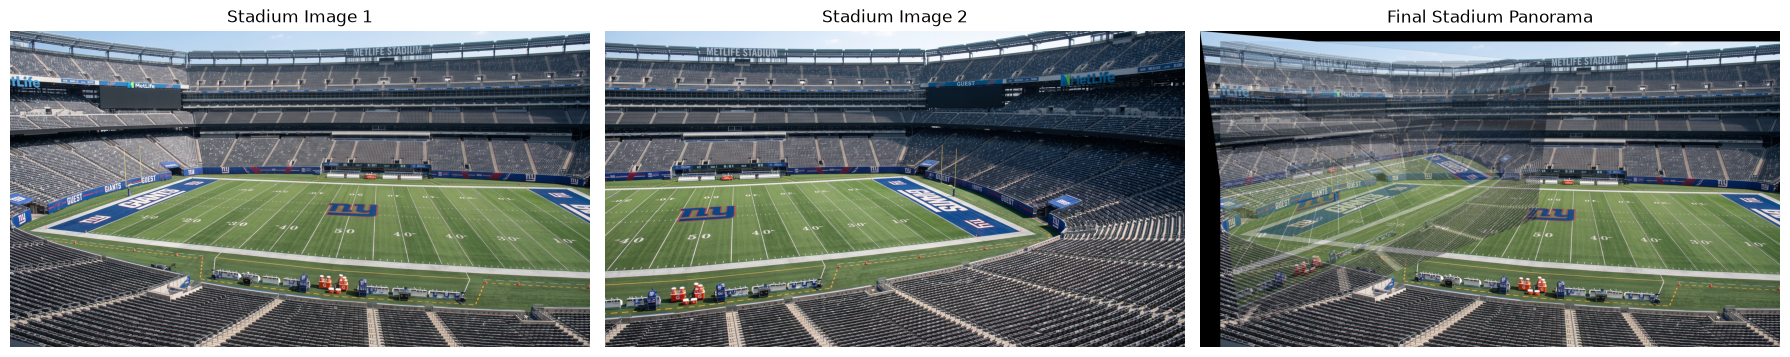

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Input and output files
# ---------------------------------------------------------
image1_path = "stadium_left.jfif"
image2_path = "stadium_right.jfif"

output_path = "task9_stadium_panorama.jpg"

# ---------------------------------------------------------
# Read both images
# ---------------------------------------------------------
a = cv2.imread(image1_path)
b = cv2.imread(image2_path)

if a is None:
    raise FileNotFoundError(f"Could not read: {image1_path}")

if b is None:
    raise FileNotFoundError(f"Could not read: {image2_path}")

h1, w1 = a.shape[:2]
h2, w2 = b.shape[:2]

print("Image 1 dimensions:", w1, "x", h1)
print("Image 2 dimensions:", w2, "x", h2)

# ---------------------------------------------------------
# FOUR MATCHING POINTS
#
# IMPORTANT:
# Replace these example points with ACTUAL matching
# points from your two stadium images.
#
# p1[i] and p2[i] must represent the SAME physical
# location in the two images.
#
# Order:
# Point 1 <-> Point 1
# Point 2 <-> Point 2
# Point 3 <-> Point 3
# Point 4 <-> Point 4
# ---------------------------------------------------------

p1 = np.array([
    [100, 100],
    [500, 100],
    [500, 400],
    [100, 400]
], dtype=np.float32)

p2 = np.array([
    [150, 120],
    [550, 100],
    [530, 420],
    [120, 400]
], dtype=np.float32)

print("\nMatching points in Image 1:")
print(p1)

print("\nMatching points in Image 2:")
print(p2)

# ---------------------------------------------------------
# Calculate homography
#
# Maps Image 2 into Image 1 coordinate space.
# ---------------------------------------------------------
H, mask = cv2.findHomography(p2, p1, cv2.RANSAC)

if H is None:
    raise ValueError("Could not calculate homography.")

print("\nHomography Image 2 -> Image 1:")
print(H)

# ---------------------------------------------------------
# Find transformed corners of Image 2
# ---------------------------------------------------------
corners2 = np.float32([
    [0, 0],
    [w2, 0],
    [w2, h2],
    [0, h2]
]).reshape(-1, 1, 2)

warped_corners = cv2.perspectiveTransform(
    corners2,
    H
).reshape(-1, 2)

print("\nWarped corners of Image 2:")
print(warped_corners)

# ---------------------------------------------------------
# Corners of Image 1
# ---------------------------------------------------------
corners1 = np.float32([
    [0, 0],
    [w1, 0],
    [w1, h1],
    [0, h1]
])

# ---------------------------------------------------------
# Find complete panorama bounding box
# ---------------------------------------------------------
all_pts = np.vstack([
    corners1,
    warped_corners
])

min_x = int(np.floor(np.min(all_pts[:, 0])))
min_y = int(np.floor(np.min(all_pts[:, 1])))

max_x = int(np.ceil(np.max(all_pts[:, 0])))
max_y = int(np.ceil(np.max(all_pts[:, 1])))

print("\nBounding box:")
print("min_x =", min_x)
print("min_y =", min_y)
print("max_x =", max_x)
print("max_y =", max_y)

# ---------------------------------------------------------
# Translation matrix
#
# Shifts everything so that the panorama starts
# at coordinate (0, 0).
# ---------------------------------------------------------
T = np.array([
    [1.0, 0.0, -min_x],
    [0.0, 1.0, -min_y],
    [0.0, 0.0, 1.0]
], dtype=np.float64)

print("\nTranslation matrix:")
print(T)

# ---------------------------------------------------------
# Final panorama dimensions
# ---------------------------------------------------------
out_w = max_x - min_x
out_h = max_y - min_y

print("\nPanorama dimensions:", out_w, "x", out_h)

# ---------------------------------------------------------
# Warp Image 2 onto panorama canvas
# ---------------------------------------------------------
pano = cv2.warpPerspective(
    b,
    T @ H,
    (out_w, out_h)
)

# ---------------------------------------------------------
# Create a mask for warped Image 2
# ---------------------------------------------------------
mask2 = np.ones(
    (h2, w2),
    dtype=np.uint8
) * 255

warped_mask2 = cv2.warpPerspective(
    mask2,
    T @ H,
    (out_w, out_h)
)

# ---------------------------------------------------------
# Place Image 1 onto panorama canvas
# ---------------------------------------------------------
x_offset = -min_x
y_offset = -min_y

pano1 = np.zeros_like(pano)

pano1[
    y_offset:y_offset + h1,
    x_offset:x_offset + w1
] = a

# ---------------------------------------------------------
# Create mask for Image 1
# ---------------------------------------------------------
mask1 = np.zeros(
    (out_h, out_w),
    dtype=np.uint8
)

mask1[
    y_offset:y_offset + h1,
    x_offset:x_offset + w1
] = 255

# ---------------------------------------------------------
# Blend the two images
# ---------------------------------------------------------
mask1_bool = mask1 > 0
mask2_bool = warped_mask2 > 0

# Start with Image 2
final = pano.copy()

# Where only Image 1 exists
only1 = mask1_bool & ~mask2_bool
final[only1] = pano1[only1]

# Where both images exist
overlap = mask1_bool & mask2_bool

# Average the overlapping pixels
final[overlap] = (
    0.5 * pano1[overlap].astype(np.float32)
    + 0.5 * pano[overlap].astype(np.float32)
).astype(np.uint8)

# ---------------------------------------------------------
# Save panorama
# ---------------------------------------------------------
cv2.imwrite(output_path, final)

print("\nSaved:", output_path)

# ---------------------------------------------------------
# Convert BGR to RGB for Jupyter
# ---------------------------------------------------------
a_rgb = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)
b_rgb = cv2.cvtColor(b, cv2.COLOR_BGR2RGB)
final_rgb = cv2.cvtColor(final, cv2.COLOR_BGR2RGB)

# ---------------------------------------------------------
# Display all results in Jupyter Notebook
# ---------------------------------------------------------
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(a_rgb)
plt.title("Stadium Image 1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(b_rgb)
plt.title("Stadium Image 2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(final_rgb)
plt.title("Final Stadium Panorama")
plt.axis("off")

plt.tight_layout()
plt.show()
